In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
accuracy_score,
confusion_matrix,
classification_report,
ConfusionMatrixDisplay,
roc_curve,
roc_auc_score
)

In [3]:
df = pd.read_csv("Cleaned_Surat_Business_Dataset.csv")

In [4]:
df.head()

,Sr.No,Area,Address/Street,Shop Name,Category,Rating,No. of Reviews,Website(Yes/No),Website Needed?(Yes/No),Opportunity Flag(High Rating + No Website)
0,1,Adajan,Pal Gam,Regnant Clothing,Clothing,4.9,243,No,Yes,Yes
1,2,Adajan,Pal Gam,Madhuram Dairy & Sweet,Dairy,4.2,13,No,No,Yes
2,3,Adajan,Pal Gam,Wallet Hypermart,Supermarket,4.2,220,No,Yes,Yes
3,4,Adajan,Pal Gam,Shri Umiya General Store,Grocery,4.8,17,No,No,Yes
4,5,Adajan,Pal Gam,Yuttam Hardware & Building Materials,Hardware Store,4.5,19,No,No,Yes


In [7]:
df.shape

(691, 10)

In [8]:
df.columns

Index(['Sr.No', 'Area', 'Address/Street', 'Shop Name', 'Category', 'Rating',
       'No. of Reviews', 'Website(Yes/No)', 'Website Needed?(Yes/No)',
       'Opportunity Flag(High Rating + No Website)'],
      dtype='str')

In [9]:
df.describe()

,Sr.No,Rating,No. of Reviews
count,691.000000,691.000000,691.000000
mean,346.000000,4.352677,405.604920
std,199.618803,1.056479,1852.213122
min,1.000000,0.000000,0.000000
25%,173.500000,4.200000,6.000000
50%,346.000000,4.700000,27.000000
75%,518.500000,4.900000,122.500000
max,691.000000,5.000000,24631.000000


In [14]:
df.isnull().sum()

Sr.No                                         0
Area                                          0
Address/Street                                0
Shop Name                                     0
Category                                      0
Rating                                        0
No. of Reviews                                0
Website(Yes/No)                               0
Website Needed?(Yes/No)                       0
Opportunity Flag(High Rating + No Website)    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

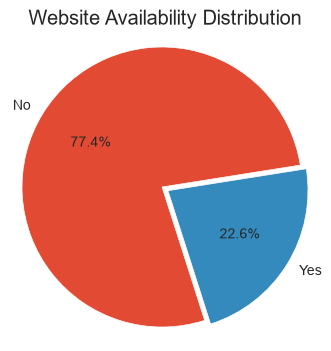

In [11]:
#Website Distribution

website_counts = df["Website(Yes/No)"].value_counts()
plt.figure(figsize=(4,4))

plt.pie(
        website_counts,
        labels=website_counts.index,
        autopct="%1.1f%%",
        startangle=9,
        explode=[0.05,0],
    )

plt.title("Website Availability Distribution")
plt.axis("equal")

plt.show()

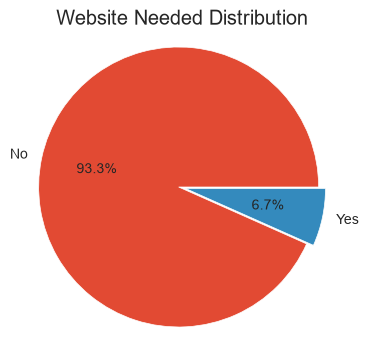

In [13]:
#Website Needed Distribution

website_needed = df["Website Needed?(Yes/No)"].value_counts()
plt.figure(figsize=(4,4))

plt.pie(
    website_needed,
    labels=website_needed.index,
    autopct="%1.1f%%",
    explode=(0.05,0),
)

plt.title("Website Needed Distribution")
plt.axis("equal")

plt.show()

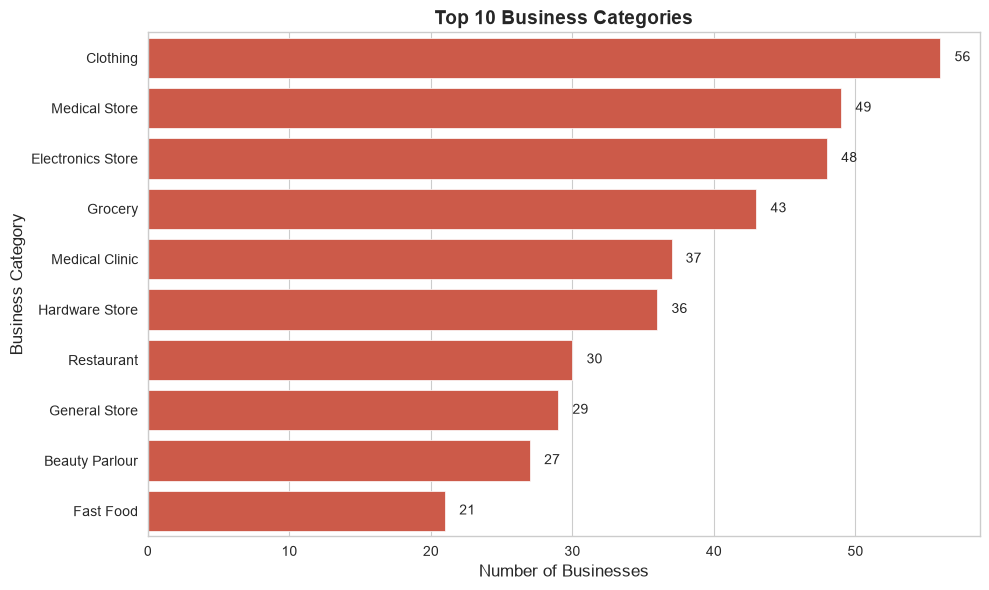

In [16]:
#Top 10 Business Categories

top_categories = df["Category"].value_counts().head(10)
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

for i, value in enumerate(top_categories.values):
    ax.text(value + 1, i, str(value), va='center', fontsize=10)

plt.title("Top 10 Business Categories", fontsize=14, fontweight="bold")
plt.xlabel("Number of Businesses")
plt.ylabel("Business Category")

plt.tight_layout()
plt.show()

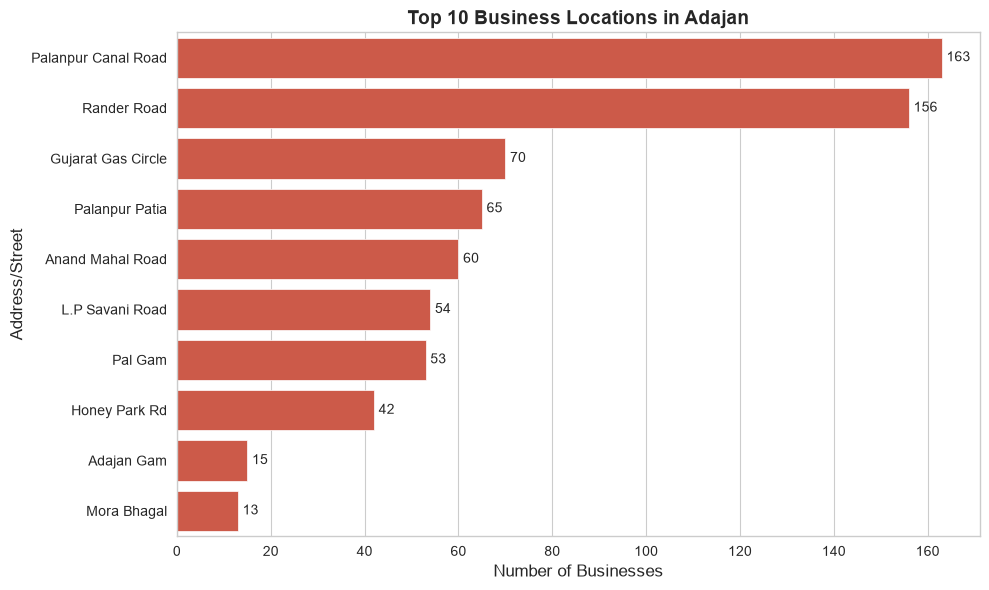

In [24]:
#Top 10 Business Location in Adajan

top_streets = df["Address/Street"].value_counts().head(10)
plt.figure(figsize=(10,6))

ax= sns.barplot(
    x=top_streets.values,
    y=top_streets.index
)

for i, value in enumerate(top_streets.values):
    ax.text(value + 1, i, str(value), va='center', fontsize=10)

plt.title("Top 10 Business Locations in Adajan", fontsize=14, fontweight="bold")
plt.xlabel("Number of Businesses")
plt.ylabel("Address/Street")

plt.tight_layout()
plt.show()

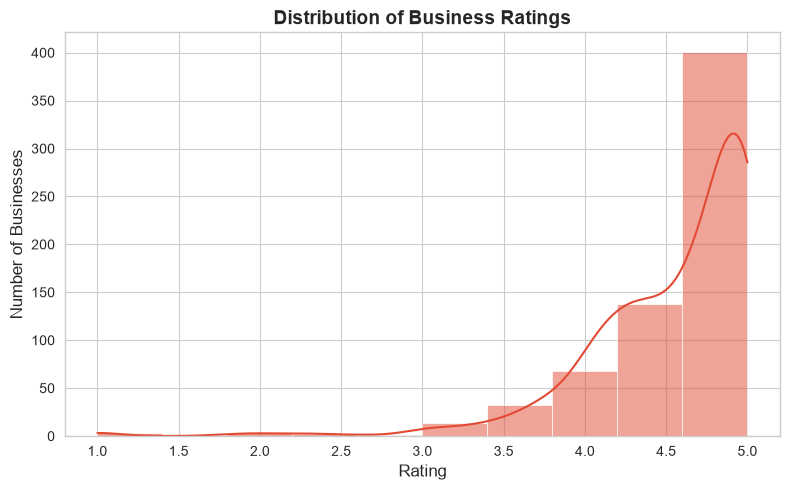

In [28]:
#Rating Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=df[df["Rating"]> 0],
    x="Rating",
    bins=10,
    kde=True
)

plt.title("Distribution of Business Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Businesses")

plt.tight_layout()
plt.show()

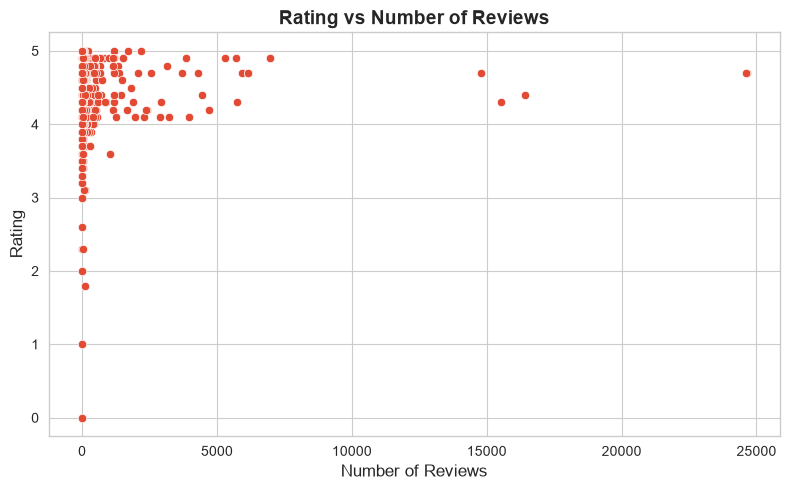

In [30]:
#Rating vs Number of Reviews
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="No. of Reviews",
    y="Rating"
)

plt.title("Rating vs Number of Reviews", fontsize=14, fontweight="bold")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

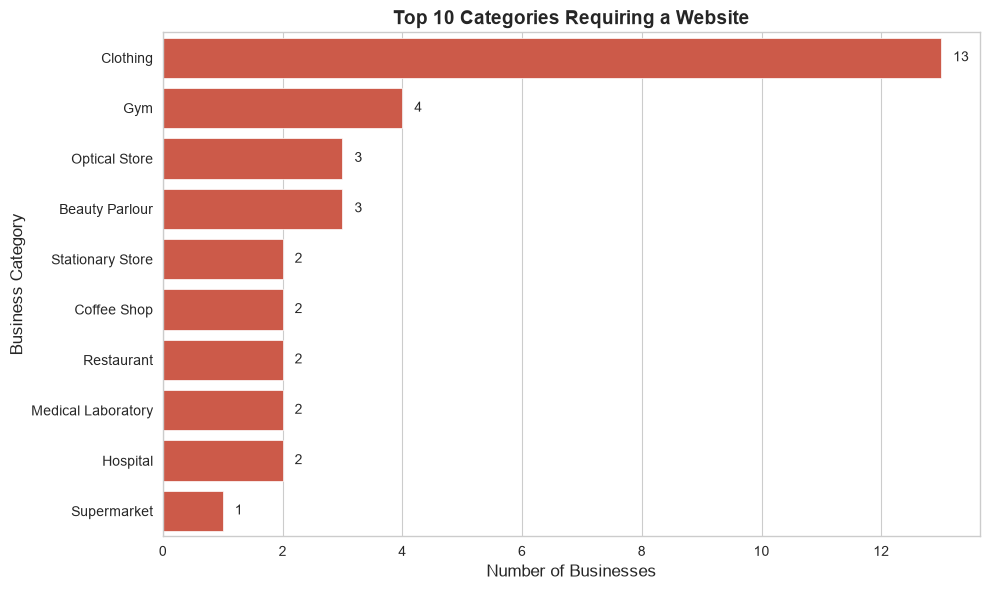

In [37]:
#Website Needed by Business Category

website_category = (
    df[df["Website Needed?(Yes/No)"] == "Yes"]
    ["Category"].value_counts().head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=website_category.values,
    y=website_category.index
)

for i, value in enumerate(website_category.values):
    ax.text(value + 0.2, i, str(value), va="center", fontsize=10)

plt.title("Top 10 Categories Requiring a Website", fontsize=14, fontweight="bold")
plt.xlabel("Number of Businesses")
plt.ylabel("Business Category")

plt.tight_layout()
plt.show()                

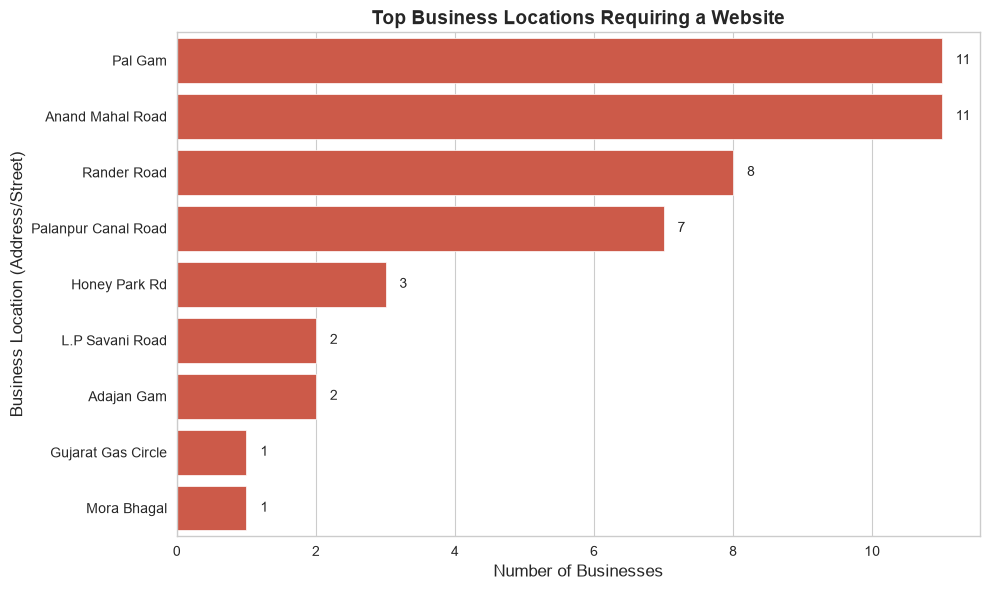

In [39]:
#Website Needed by Business Location

website_location = (
    df[df["Website Needed?(Yes/No)"] == "Yes"]["Address/Street"].value_counts().head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=website_location.values,
    y=website_location.index
)

for i, value in enumerate(website_location.values):
    ax.text(value + 0.2, i, str(value), va="center", fontsize=10)

plt.title("Top Business Locations Requiring a Website", fontsize=14, fontweight="bold")
plt.xlabel("Number of Businesses")
plt.ylabel("Business Location (Address/Street)")

plt.tight_layout()
plt.show()

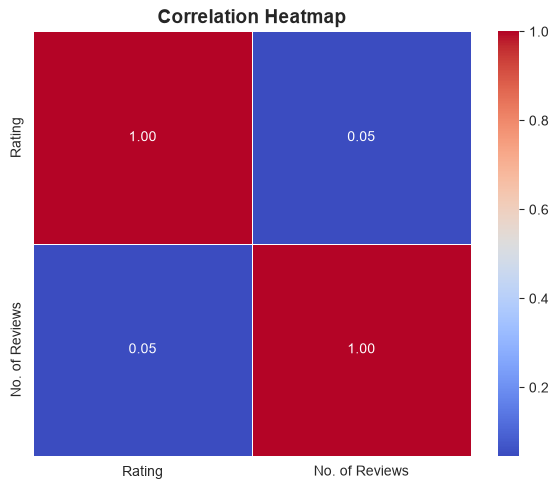

In [41]:
#Correlation Heatmap

numeric_df = df[["Rating", "No. of Reviews"]]

plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [5]:
#Features(X)

X = df[["Category","Address/Street","Rating","No. of Reviews","Website(Yes/No)"]]

#Target

y = df["Website Needed?(Yes/No)"]

print("Feature Shape :", X.shape)
print("Feature Shape :", y.shape)

X.head()

Feature Shape : (691, 5)
Feature Shape : (691,)


,Category,Address/Street,Rating,No. of Reviews,Website(Yes/No)
0,Clothing,Pal Gam,4.9,243,No
1,Dairy,Pal Gam,4.2,13,No
2,Supermarket,Pal Gam,4.2,220,No
3,Grocery,Pal Gam,4.8,17,No
4,Hardware Store,Pal Gam,4.5,19,No


In [6]:
#Create LabelEncoder object

le = LabelEncoder()

X["Category"] = le.fit_transform(X["Category"])
X["Address/Street"] = le.fit_transform(X["Address/Street"])
X["Website(Yes/No)"] = le.fit_transform(X["Website(Yes/No)"])

y = le.fit_transform(y)

print(X.head())
print("\nTarget Values:")
print(np.unique(y))

   Category  Address/Street  Rating  No. of Reviews  Website(Yes/No)
0        18               6     4.9             243                0
1        26               6     4.2              13                0
2        93               6     4.2             220                0
3        45               6     4.8              17                0
4        49               6     4.5              19                0

Target Values:
[0 1]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (552, 5)
Testing Features : (139, 5)
Training Target : (552,)
Testing Target : (139,)


In [8]:
#Logistics Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Create Model
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

#Train Model
lr_model.fit(X_train, y_train)

#Predictions
lr_predictions = lr_model.predict(X_test)

#Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistics Regression Accuracy:", round(lr_accuracy*100,2), "%")

print("\nClassification Report")
print(classification_report(y_test, lr_predictions, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_predictions))

Logistics Regression Accuracy: 60.43 %

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.59      0.74       130
           1       0.12      0.78      0.20         9

    accuracy                           0.60       139
   macro avg       0.55      0.69      0.47       139
weighted avg       0.92      0.60      0.70       139


Confusion Matrix
[[77 53]
 [ 2  7]]


Decision Tree Accuracy: 92.81 %

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       130
           1       0.43      0.33      0.38         9

    accuracy                           0.93       139
   macro avg       0.69      0.65      0.67       139
weighted avg       0.92      0.93      0.92       139


Confusion Matrix
[[126   4]
 [  6   3]]


<Figure size 500x400 with 0 Axes>

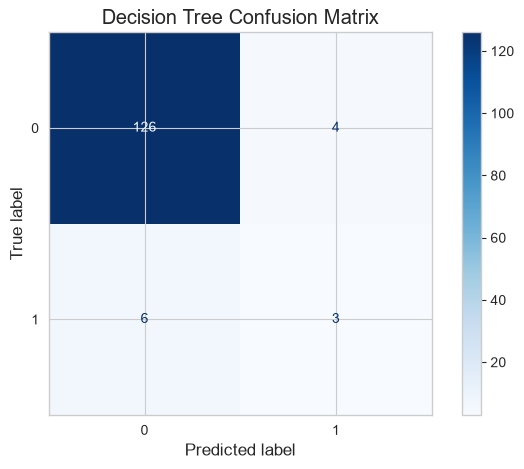

In [9]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

#Create Model
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

#Train Model
dt_model.fit(X_train, y_train)

#Predictions
dt_predictions = dt_model.predict(X_test)

#Accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2), "%")

print("\nClassification Report")
print(classification_report(y_test, dt_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_predictions))

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot Decision Tree Confusion Matrix
plt.figure(figsize=(5,4))

ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "decision_tree_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [10]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

#Create Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

#Train Model
rf_model.fit(X_train, y_train)

#Predictions
rf_predictions = rf_model.predict(X_test)

#Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy*100,2) ,"%")

print("\nClassification Report")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy: 92.09 %

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       130
           1       0.38      0.33      0.35         9

    accuracy                           0.92       139
   macro avg       0.66      0.65      0.66       139
weighted avg       0.92      0.92      0.92       139


Confusion Matrix
[[125   5]
 [  6   3]]


In [11]:
#Compare Models
from sklearn.metrics import precision_score, recall_score, f1_score
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
    ],
    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Recall":[
        recall_score(y_test, lr_predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions)             
    ],
    "Precision":[
        precision_score(y_test, lr_predictions),
        precision_score(y_test, dt_predictions),
        precision_score(y_test, rf_predictions)             
    ],
    "F1":[
        f1_score(y_test, lr_predictions),
        f1_score(y_test, dt_predictions),
        f1_score(y_test, rf_predictions)             
    ]
})

results[["Accuracy","Recall","Precision","F1"]] = results[["Accuracy","Recall","Precision","F1"]] * 100

results.sort_values(by="F1", ascending=False)

,Model,Accuracy,Recall,Precision,F1
1,Decision Tree,92.805755,33.333333,42.857143,37.500000
2,Random Forest,92.086331,33.333333,37.500000,35.294118
0,Logistic Regression,60.431655,77.777778,11.666667,20.289855


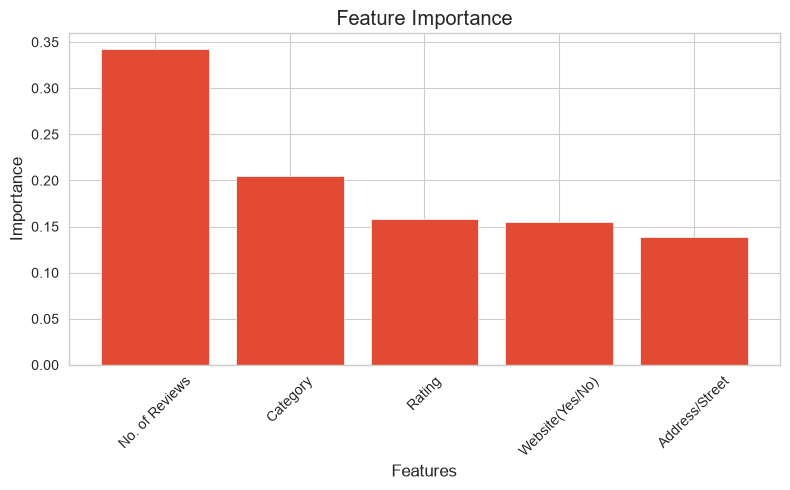

In [12]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
print(feature_importance)

           Feature  Importance
3   No. of Reviews    0.342420
0         Category    0.205224
2           Rating    0.158340
4  Website(Yes/No)    0.155237
1   Address/Street    0.138779


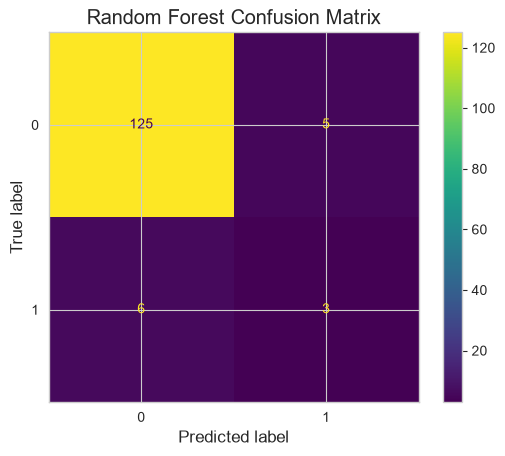

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test, 
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

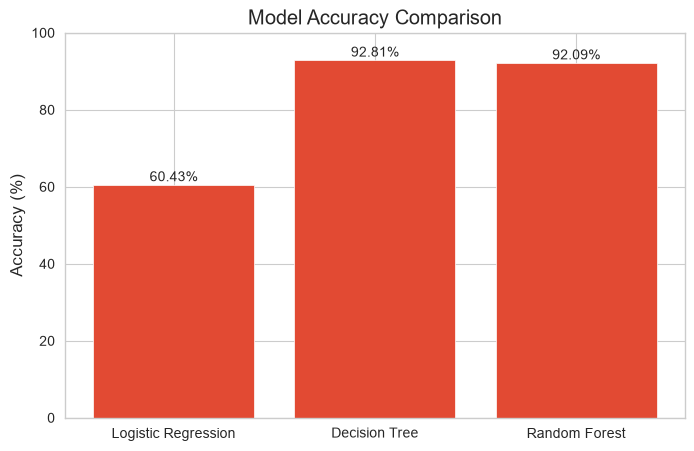

In [38]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [lr_accuracy*100, dt_accuracy*100, rf_accuracy*100]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0,100)

for i, v in enumerate(accuracy):
    plt.text(i, v+1, f"{v:.2f}%", ha="center")

plt.show()